In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Binomial distribution

- calculates probability of exactly $k$ successes occurring in $n$ trials

- success rate is defined with probability $p$

$$

\begin{align*}
P(X=k) &= \binom{n}{k} p^{k} (1 - p)^{n-k} \\
P(X \leq k) &= \sum_{i=0}^{k} \binom{n}{i} p^{i} (1 - p)^{n-i} \\
E[X] &= np \\
\text{Var}(X) &= np(1-p)
\end{align*}

$$

- binomial coefficient $\binom{n}{k}$ counts in how many ways the specific outcome can be arranged (number of combinations)

- probability of success $p^k$ represents success happening exactly $k$ times with probability $p$

- probability of failure $(1-p)^{n-k}$ represents failure happening exactly $n-k$ times with probability $(1-p)$

***

### Example

Given a 10 question multiple choice exam where every question has 4 possible answers, what is the probability that the student gets exactly 4 questions correct by guessing?

 - probability of success $p=\frac{1}{4}$
 - probability of failure $1-p=\frac{3}{4}$
 - probability of guessing 4 out of 10 correct $P(X = 4) = \binom{10}{4} \cdot \left( \frac{1}{4} \right)^{4} \cdot \left( \frac{3}{4} \right)^{10-4} = 210 \cdot \frac{1}{256} \cdot \frac{729}{4096} = 0.14599$

### Explanation

- one possible sequence for guessing 4 correct out of 10 is SSSSFFFFFF

- since $n$ trials are indepedent events probabilities are multiplied, $\left( \frac{1}{4} \right)^{4} \cdot \left( \frac{3}{4} \right)^{6}$

- probability of these outcomes is always the same, whether SSSSFFFFFF, SFSSSFFFFF, SSFSSFFFFF...

- to find all possible combinations where we choose 4 successes out of 10 trials binomial coefficient $\binom{10}{4}$ is used

- summing all possible combinations we obtain the expression $\binom{10}{4} \cdot \left( \frac{1}{4} \right)^{4} \cdot \left( \frac{3}{4} \right)^{6}$

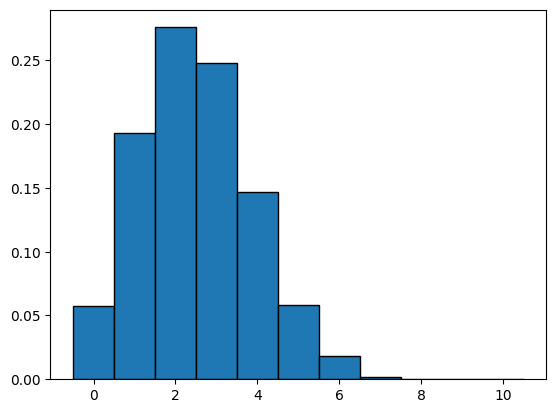

In [2]:
p = 0.25 # probability of success
n = 10 # number of trials

x = np.random.binomial(n, p, size=10000)
plt.hist(x, edgecolor="black", bins=np.arange(n + 2) - 0.5, density=True)
plt.show()

In [3]:
from scipy.stats import binom

k = 4
prob = binom.pmf(k, n, p)
print(f'Probability for answering 4 out of 10 questions at random: {prob}')

Probability for answering 4 out of 10 questions at random: 0.14599800109863273


# Sampling from binomial distribution

- generate $n$ random uniform numbers, $x \sim \text{Uniform}(0, 1)$

- if $x < p$ it counts as a success and failure otherwise

- sum over all the $n$ trials (True - 1, False - 0) to get total number of successes

In [4]:
def generate_random_binomial(n, p, size=1):
    trials = np.random.rand(size, n)
    successes = trials < p
    return np.sum(successes, axis=1)

# Example usage
samples = generate_random_binomial(n, p, size=10000)
print("Binomial samples:", samples)

Binomial samples: [2 3 2 ... 3 2 0]


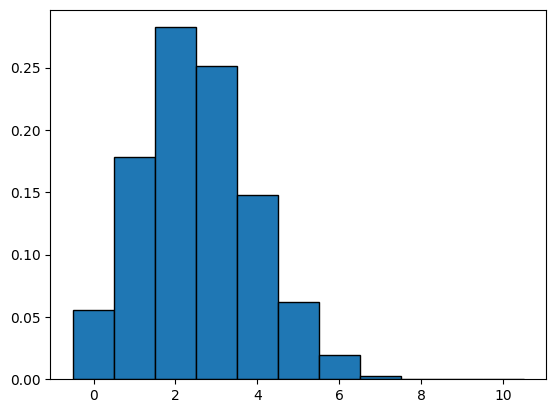

In [5]:
plt.hist(samples, edgecolor="black", bins=np.arange(n + 2) - 0.5, density=True)
plt.show()